In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt



### Loading and understanding Data

In [2]:
df = pd.read_csv('weatherAUS.csv')
df.info()
# 145k rows 23 column

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null   float64


In [3]:
df.isnull().sum()

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64

In [4]:
df.sample(10)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
121448,2010-09-19,Perth,8.6,23.1,0.0,4.2,11.0,E,33.0,E,...,54.0,25.0,1032.8,1027.8,0.0,0.0,14.3,22.4,No,No
122513,2013-11-16,Perth,19.6,37.1,0.0,13.0,13.0,WNW,31.0,ENE,...,28.0,25.0,1011.0,1009.0,4.0,2.0,30.0,32.1,No,No
87690,2010-04-05,Cairns,22.7,29.8,31.2,3.2,2.2,ENE,37.0,S,...,82.0,84.0,1012.0,1009.6,6.0,7.0,26.5,26.7,Yes,Yes
66688,2016-01-31,MelbourneAirport,14.5,20.6,8.8,4.8,8.2,NNE,56.0,NNE,...,73.0,58.0,1000.5,1001.7,7.0,7.0,17.1,18.9,Yes,No
48061,2014-11-07,Canberra,5.3,27.4,0.0,NaN,NaN,ENE,39.0,SE,...,75.0,18.0,1019.1,1017.4,NaN,NaN,14.6,25.7,No,No
65700,2013-05-18,MelbourneAirport,7.9,13.5,0.0,1.2,0.8,SSW,39.0,W,...,77.0,67.0,1018.0,1016.8,7.0,6.0,10.8,12.0,No,No
69766,2015-10-08,Melbourne,NaN,NaN,NaN,6.6,10.5,SSE,31.0,W,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10121,2011-12-30,CoffsHarbour,17.8,25.9,0.0,8.0,11.9,S,44.0,SW,...,57.0,49.0,1016.3,1016.5,4.0,1.0,21.7,24.9,No,Yes
62600,2013-01-19,Sale,9.6,23.3,0.0,6.8,12.4,SE,39.0,WNW,...,63.0,41.0,1016.0,1015.1,8.0,7.0,17.1,22.0,No,No
1005,2011-10-02,Albury,4.2,17.6,5.8,NaN,NaN,SSE,35.0,S,...,69.0,47.0,1018.4,1018.1,NaN,NaN,11.3,14.8,Yes,No


#### Corolation between features & Target

In [5]:
cols = ['MinTemp',	'MaxTemp', 'Rainfall', 'Evaporation','Sunshine','WindGustSpeed',
        'Humidity9am','Humidity3pm','Pressure9am','Pressure3pm','Cloud9am','Cloud3pm','Temp9am','Temp3pm']

correlation_matrix = df[cols].corr()
correlation_matrix

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
MinTemp,1.000000,0.736555,0.103938,0.466993,0.072586,0.177415,-0.232899,0.006089,-0.450970,-0.461292,0.078754,0.021605,0.901821,0.708906
MaxTemp,0.736555,1.000000,-0.074992,0.587932,0.470156,0.067615,-0.504110,-0.508855,-0.332061,-0.427167,-0.289370,-0.277921,0.887210,0.984503
Rainfall,0.103938,-0.074992,1.000000,-0.064351,-0.227549,0.133659,0.224405,0.255755,-0.168154,-0.126534,0.198528,0.172403,0.011192,-0.079657
Evaporation,0.466993,0.587932,-0.064351,1.000000,0.365602,0.203021,-0.504092,-0.390243,-0.270362,-0.293581,-0.183793,-0.182618,0.545115,0.572893
Sunshine,0.072586,0.470156,-0.227549,0.365602,1.000000,-0.034750,-0.490819,-0.629130,0.041970,-0.019719,-0.675323,-0.703930,0.291188,0.490501
WindGustSpeed,0.177415,0.067615,0.133659,0.203021,-0.034750,1.000000,-0.215070,-0.026327,-0.458744,-0.413749,0.071736,0.109168,0.150150,0.032748
Humidity9am,-0.232899,-0.504110,0.224405,-0.504092,-0.490819,-0.215070,1.000000,0.666949,0.139442,0.186858,0.452297,0.357326,-0.471354,-0.498399
Humidity3pm,0.006089,-0.508855,0.255755,-0.390243,-0.629130,-0.026327,0.666949,1.000000,-0.027544,0.051997,0.517120,0.523120,-0.221019,-0.557841
Pressure9am,-0.450970,-0.332061,-0.168154,-0.270362,0.041970,-0.458744,0.139442,-0.027544,1.000000,0.961326,-0.129796,-0.147861,-0.422556,-0.286770
Pressure3pm,-0.461292,-0.427167,-0.126534,-0.293581,-0.019719,-0.413749,0.186858,0.051997,0.961326,1.000000,-0.060772,-0.084778,-0.470187,-0.389548


In [6]:
df['target_tmp'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})

for c in cols:
    corr_value = df[[c, 'target_tmp']].corr().iloc[0, 1]
    print(f"{c}: {corr_value:.3f}")

MinTemp: 0.084
MaxTemp: -0.159
Rainfall: 0.239
Evaporation: -0.119
Sunshine: -0.451
WindGustSpeed: 0.234
Humidity9am: 0.257
Humidity3pm: 0.446
Pressure9am: -0.246
Pressure3pm: -0.226
Cloud9am: 0.317
Cloud3pm: 0.382
Temp9am: -0.026
Temp3pm: -0.192


In [7]:
# these features have bigger corralations between.
cols = ['MinTemp',	'MaxTemp', 'Rainfall', 'Pressure9am','Pressure3pm','Temp9am','Temp3pm']

correlation_matrix = df[cols].corr()
correlation_matrix

,MinTemp,MaxTemp,Rainfall,Pressure9am,Pressure3pm,Temp9am,Temp3pm
MinTemp,1.000000,0.736555,0.103938,-0.450970,-0.461292,0.901821,0.708906
MaxTemp,0.736555,1.000000,-0.074992,-0.332061,-0.427167,0.887210,0.984503
Rainfall,0.103938,-0.074992,1.000000,-0.168154,-0.126534,0.011192,-0.079657
Pressure9am,-0.450970,-0.332061,-0.168154,1.000000,0.961326,-0.422556,-0.286770
Pressure3pm,-0.461292,-0.427167,-0.126534,0.961326,1.000000,-0.470187,-0.389548
Temp9am,0.901821,0.887210,0.011192,-0.422556,-0.470187,1.000000,0.860591
Temp3pm,0.708906,0.984503,-0.079657,-0.286770,-0.389548,0.860591,1.000000


In [8]:
# dropping temp9am and temp3pm
# Pressure9am/Pressure3pm drop 9am keep 3pm due to 96corr 
# TempRange = MaxTemp - MinTemp (Temp range gives us hint because cloudy days have more temprange than sunny days)
# Evaportaion feature half empty and 0.11 corolation 
df['TempRange'] = df['MaxTemp'] - df['MinTemp']
df = df.drop(columns=['Temp9am','Temp3pm','Pressure9am','Evaporation'])


#### Sunshine column has great corrolation with Target but half empty -> I will add medians of a location + month median. 

In [9]:
df['Date'] = pd.to_datetime(df['Date'])

# 49 locaitons
df['Location'].unique()

df['Sunshine'] = df.groupby(['Location', df['Date'].dt.month])['Sunshine'].transform(lambda x: x.fillna(x.median()))

In [10]:
# We will keep months as Date.month Sin and Cos 
df['Date'] = pd.to_datetime(df['Date'])
df['Month_sin'] = np.sin(2*np.pi*df['Date'].dt.month/12)
df['Month_cos'] = np.cos(2*np.pi*df['Date'].dt.month/12)

In [11]:
# Target column 3.2k rows Nan
df = df.dropna(subset=['RainTomorrow'])

# 1.4k RainToday Nan
df = df.dropna(subset=['RainToday'])


# Convert RainToday and Tomorrow
df['RainToday'] = df['RainToday'].map({'Yes': 1, 'No': 0})
df['RainTomorrow'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})

In [12]:
# All other columns Filling Nan values with Location+Month [column] structure
cols_to_impute = ['MinTemp','MaxTemp','Sunshine','WindGustSpeed',
                   'WindSpeed9am','WindSpeed3pm','Humidity9am','Humidity3pm',
                   'Pressure3pm','Cloud9am','Cloud3pm','TempRange']

for col in cols_to_impute:
    df[col] = df.groupby(['Location', df['Date'].dt.month])[col]\
                .transform(lambda x: x.fillna(x.median()))
    
    df[col] = df[col].fillna(df[col].median())

In [13]:
wind_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm']

for col in wind_cols:
    df[col] = df.groupby(['Location', df['Date'].dt.month])[col]\
                .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan))
    df[col] = df[col].fillna(df[col].mode()[0])

In [14]:
# Compass values to sin-cos circle values
compass = ['N','NNE','NE','ENE','E','ESE','SE','SSE','S','SSW','SW','WSW','W','WNW','NW','NNW']
deg_map = {d: i*22.5 for i, d in enumerate(compass)}

df['WindGustDir_deg'] = df['WindGustDir'].map(deg_map)
df['WindGustDir_sin'] = np.sin(np.radians(df['WindGustDir_deg']))
df['WindGustDir_cos'] = np.cos(np.radians(df['WindGustDir_deg']))

df['WindDir9am_deg'] = df['WindDir9am'].map(deg_map)
df['WindDir9am_sin'] = np.sin(np.radians(df['WindDir9am_deg']))
df['WindDir9am_cos'] = np.cos(np.radians(df['WindDir9am_deg']))

df['WindDir3pm_deg'] = df['WindDir3pm'].map(deg_map)
df['WindDir3pm_sin'] = np.sin(np.radians(df['WindDir3pm_deg']))
df['WindDir3pm_cos'] = np.cos(np.radians(df['WindDir3pm_deg']))

df = df.drop(columns=['WindGustDir', 'WindDir9am', 'WindDir3pm',
                       'WindGustDir_deg', 'WindDir9am_deg', 'WindDir3pm_deg'])


# drop wind columns
# df = df.drop(columns=['WindGustDir', 'WindDir9am', 'WindDir3pm'])

In [15]:

# Location One hot encoding
df = pd.get_dummies(df, columns=['Location'], prefix='Loc')

In [16]:
df = df.drop(columns=['target_tmp'])

### Train Test

In [17]:
df = df.sort_values('Date').reset_index(drop=True)

In [18]:
cutoff_date = df['Date'].quantile(0.8)
print("Kəsmə tarixi:", cutoff_date)

train_df = df[df['Date'] <= cutoff_date]
test_df  = df[df['Date'] > cutoff_date]

print("Train ölçüsü:", train_df.shape)
print("Test ölçüsü:", test_df.shape)

Kəsmə tarixi: 2015-11-10 00:00:00
Train ölçüsü: (112668, 73)
Test ölçüsü: (28119, 73)


In [19]:
y_train = train_df['RainTomorrow']
y_test  = test_df['RainTomorrow']

X_train = train_df.drop(columns=['RainTomorrow', 'Date'])
X_test  = test_df.drop(columns=['RainTomorrow', 'Date'])

In [20]:
from sklearn.preprocessing import StandardScaler

continuous_cols = ['MinTemp', 'MaxTemp', 'Rainfall', 'Sunshine', 'WindGustSpeed',
                    'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
                    'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'TempRange']

scaler = StandardScaler()
scaler.fit(X_train[continuous_cols])

X_train[continuous_cols] = scaler.transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

print(X_train[continuous_cols].describe().loc[['mean','std']])

           MinTemp       MaxTemp      Rainfall      Sunshine  WindGustSpeed  \
mean  1.614469e-17  3.067490e-16  1.009043e-17  4.803044e-16   1.170490e-16   
std   1.000004e+00  1.000004e+00  1.000004e+00  1.000004e+00   1.000004e+00   

      WindSpeed9am  WindSpeed3pm   Humidity9am   Humidity3pm   Pressure3pm  \
mean -6.760587e-17  4.641597e-17 -1.594288e-16  1.271394e-16 -8.992590e-15   
std   1.000004e+00  1.000004e+00  1.000004e+00  1.000004e+00  1.000004e+00   

          Cloud9am      Cloud3pm     TempRange  
mean  2.018086e-17  1.301665e-16 -3.027128e-16  
std   1.000004e+00  1.000004e+00  1.000004e+00  


In [21]:
# binary classification → sigmoid + binary_crossentropy
n_features = X_train.shape[1]

model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           4,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,721 (26.25 KB)

 Trainable params: 6,721 (26.25 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
2817/2817 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8487 - loss: 0.3451 - val_accuracy: 0.8616 - val_loss: 0.3198
Epoch 2/30
2817/2817 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8615 - loss: 0.3212 - val_accuracy: 0.8630 - val_loss: 0.3163
Epoch 3/30
2817/2817 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8659 - loss: 0.3123 - val_accuracy: 0.8642 - val_loss: 0.3153
Epoch 4/30
2817/2817 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8686 - loss: 0.3066 - val_accuracy: 0.8649 - val_loss: 0.3152
Epoch 5/30
2817/2817 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8706 - loss: 0.3025 - val_accuracy: 0.8650 - val_loss: 0.3147
Epoch 6/30
2817/2817 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8718 - loss: 0.2991 - val_accuracy: 0.8631 - val_loss: 0.3251
Epoch 7/30
2817/2817 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8730 - loss: 0.2970 - val_accuracy: 0.8671 - val_loss: 0.3137
Epoch 8/30
2817/2817 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8745 - loss: 0.2944 - 

In [23]:
n_features = X_train.shape[1]

model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
2817/2817 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8506 - loss: 0.3415 - val_accuracy: 0.8618 - val_loss: 0.3225
Epoch 2/50
2817/2817 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8621 - loss: 0.3196 - val_accuracy: 0.8630 - val_loss: 0.3178
Epoch 3/50
2817/2817 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8651 - loss: 0.3115 - val_accuracy: 0.8646 - val_loss: 0.3123
Epoch 4/50
2817/2817 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8676 - loss: 0.3063 - val_accuracy: 0.8645 - val_loss: 0.3136
Epoch 5/50
2817/2817 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8688 - loss: 0.3024 - val_accuracy: 0.8654 - val_loss: 0.3113
Epoch 6/50
2817/2817 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8706 - loss: 0.2991 - val_accuracy: 0.8655 - val_loss: 0.3098
Epoch 7/50
2817/2817 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8719 - loss: 0.2967 - val_accuracy: 0.8658 - val_loss: 0.3113
Epoch 8/50
2817/2817 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8731 - loss: 0.2944 - 

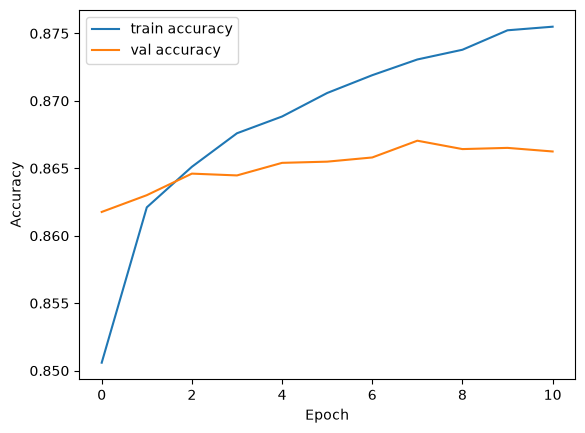

In [24]:

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

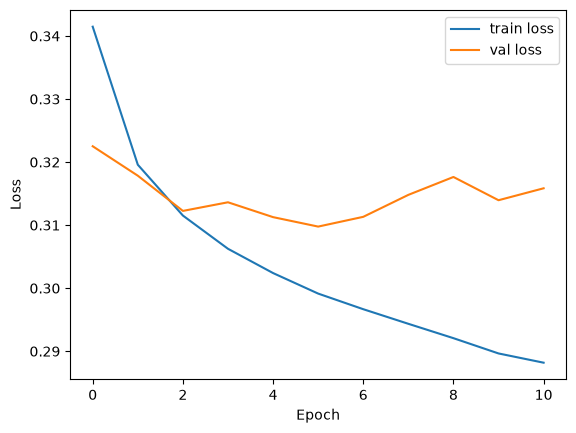

In [25]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [26]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

879/879 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8597 - loss: 0.3268
Test loss: 0.32675617933273315
Test accuracy: 0.8596678376197815


### Prediction

In [27]:
y_pred = model.predict(X_test)

y_pred_class = (y_pred > 0.5).astype(int)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_class)

print(cm)

879/879 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
[[20627  1282]
 [ 2664  3546]]


In [28]:

print(classification_report(y_test, y_pred_class))

              precision    recall  f1-score   support

           0       0.89      0.94      0.91     21909
           1       0.73      0.57      0.64      6210

    accuracy                           0.86     28119
   macro avg       0.81      0.76      0.78     28119
weighted avg       0.85      0.86      0.85     28119

